#Feature Engineering

"Quando a fábrica está operando em alta capacidade vs baixa capacidade?"

📊 CONSUMO MÉDIO POR HORA DO DIA

Hora | Consumo Médio | Desvio Padrão | Registros
----------------------------------------------------------------------
  0h |    7.87 kWh |   16.06 kWh | 1,460
  1h |    6.07 kWh |   12.01 kWh | 1,460
  2h |    4.43 kWh |    6.58 kWh | 1,460
  3h |    4.36 kWh |    6.38 kWh | 1,460
  4h |    4.31 kWh |    6.43 kWh | 1,460
  5h |    4.25 kWh |    6.49 kWh | 1,460
  6h |    4.22 kWh |    6.76 kWh | 1,460
  7h |    4.50 kWh |    6.49 kWh | 1,460
  8h |   37.70 kWh |   33.31 kWh | 1,460
  9h |   58.55 kWh |   34.89 kWh | 1,460
 10h |   55.87 kWh |   33.59 kWh | 1,460
 11h |   57.10 kWh |   34.22 kWh | 1,460
 12h |   18.46 kWh |   26.43 kWh | 1,460
 13h |   39.02 kWh |   34.00 kWh | 1,460
 14h |   56.16 kWh |   33.79 kWh | 1,460
 15h |   55.64 kWh |   33.79 kWh | 1,460
 16h |   55.80 kWh |   34.34 kWh | 1,460
 17h |   43.83 kWh |   34.33 kWh | 1,460
 18h |   33.02 kWh |   29.36 kWh | 1,460
 19h |   38.21 kWh |   34.47 kWh | 1,460
 20h |   37.45 kWh |   34.4

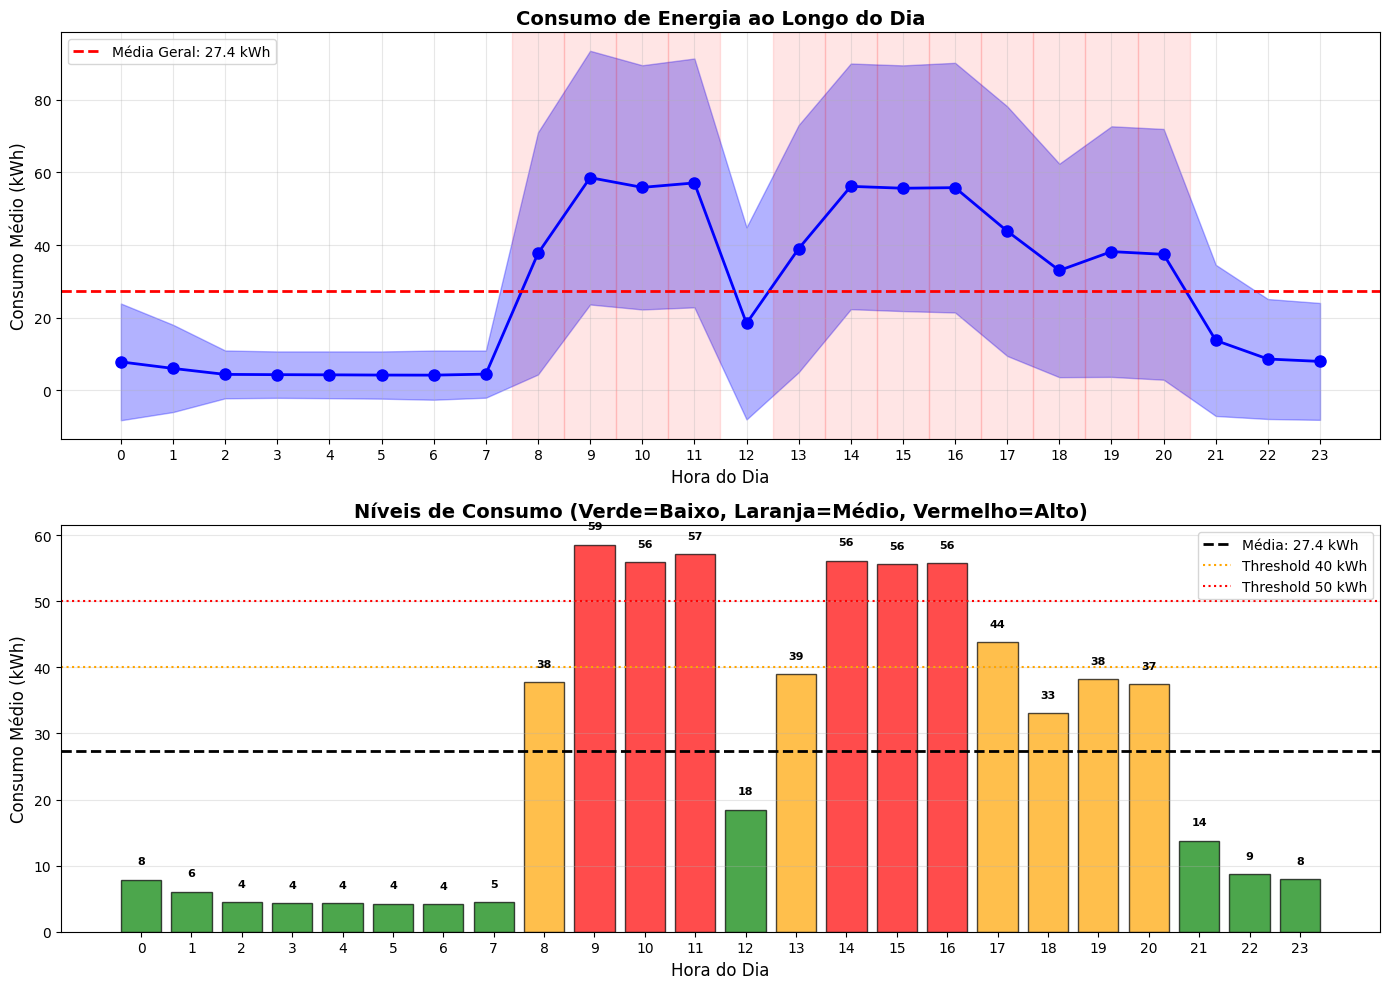



🔴 ALTO consumo (>50 kWh): 6 horas
   Horários: [9, 10, 11, 14, 15, 16]

🟠 MÉDIO consumo (30-50 kWh): 6 horas
   Horários: [8, 13, 17, 18, 19, 20]

🟢 BAIXO consumo (<30 kWh): 12 horas
   Horários: [0, 1, 2, 3, 4, 5, 6, 7, 12, 21, 22, 23]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# CARREGAR DADOS
# ============================================
df = pd.read_csv('../data/processed/data_clean.csv')

# ============================================
# CALCULAR ESTATÍSTICAS POR HORA
# ============================================
hourly_stats = df.groupby('Hour')['Usage_kWh'].agg(['mean', 'std', 'count'])

# ============================================
# IMPRIMIR TABELA DE VALORES
# ============================================
print("="*70)
print("📊 CONSUMO MÉDIO POR HORA DO DIA")
print("="*70)
print("\nHora | Consumo Médio | Desvio Padrão | Registros")
print("-" * 70)
for hour in range(24):
    stats = hourly_stats.loc[hour]
    print(f" {hour:2d}h | {stats['mean']:7.2f} kWh | {stats['std']:7.2f} kWh | {int(stats['count']):,}")

# ============================================
# CRIAR FIGURA COM 2 SUBPLOTS (GRÁFICOS)
# ============================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
# 2 linhas, 1 coluna de gráficos
# figsize=(largura, altura) em polegadas

# ============================================
# GRÁFICO 1: LINHA COM ÁREA DE DESVIO PADRÃO
# ============================================
hours = hourly_stats.index  # [0, 1, 2, ..., 23]
means = hourly_stats['mean'].values  # Array com médias
stds = hourly_stats['std'].values  # Array com desvios

# Linha principal
axes[0].plot(hours, means, 
             marker='o',      # Marcador circular em cada ponto
             linewidth=2,     # Espessura da linha
             markersize=8,    # Tamanho dos marcadores
             color='blue')

# Área sombreada (média ± desvio padrão)
axes[0].fill_between(hours, 
                      means - stds,  # Limite inferior
                      means + stds,  # Limite superior
                      alpha=0.3,     # Transparência (0-1)
                      color='blue')

# Linha horizontal da média geral
axes[0].axhline(y=df['Usage_kWh'].mean(),  # Valor Y da linha
                color='red', 
                linestyle='--',  # Linha tracejada
                linewidth=2, 
                label=f'Média Geral: {df["Usage_kWh"].mean():.1f} kWh')

# Configurações do gráfico
axes[0].set_xlabel('Hora do Dia', fontsize=12)
axes[0].set_ylabel('Consumo Médio (kWh)', fontsize=12)
axes[0].set_title('Consumo de Energia ao Longo do Dia', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)  # Grade com transparência
axes[0].set_xticks(range(0, 24))  # Marcar todas as 24 horas
axes[0].legend(fontsize=10)

# Destacar horários acima da média com fundo vermelho
for hour in range(24):
    mean_val = hourly_stats.loc[hour, 'mean']
    if mean_val > df['Usage_kWh'].mean():
        # axvspan = vertical span (faixa vertical)
        axes[0].axvspan(hour - 0.5, hour + 0.5, 
                        alpha=0.1, color='red')

# ============================================
# GRÁFICO 2: BARRAS COM CÓDIGO DE CORES
# ============================================

# Definir cores baseadas em thresholds
colors = []
for hour in range(24):
    mean_val = hourly_stats.loc[hour, 'mean']
    if mean_val > 50:  # Alto
        colors.append('red')
    elif mean_val > 30:  # Médio
        colors.append('orange')
    else:  # Baixo
        colors.append('green')

# Criar barras
axes[1].bar(hours, means, 
            color=colors, 
            alpha=0.7,          # Transparência
            edgecolor='black')  # Borda preta

# Linhas horizontais de referência
axes[1].axhline(y=df['Usage_kWh'].mean(), 
                color='black', 
                linestyle='--', 
                linewidth=2, 
                label=f'Média: {df["Usage_kWh"].mean():.1f} kWh')

axes[1].axhline(y=40, 
                color='orange', 
                linestyle=':', 
                linewidth=1.5, 
                label='Threshold 40 kWh')

axes[1].axhline(y=50, 
                color='red', 
                linestyle=':', 
                linewidth=1.5, 
                label='Threshold 50 kWh')

# Configurações
axes[1].set_xlabel('Hora do Dia', fontsize=12)
axes[1].set_ylabel('Consumo Médio (kWh)', fontsize=12)
axes[1].set_title('Níveis de Consumo (Verde=Baixo, Laranja=Médio, Vermelho=Alto)', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')  # Grade só no eixo Y
axes[1].set_xticks(range(0, 24))
axes[1].legend(fontsize=10)

# Adicionar valores em cima das barras
for i, (hour, mean_val) in enumerate(zip(hours, means)):
    axes[1].text(hour,           # Posição X
                 mean_val + 2,   # Posição Y (2 kWh acima da barra)
                 f'{mean_val:.0f}',  # Texto (arredondado)
                 ha='center',    # Alinhamento horizontal
                 va='bottom',    # Alinhamento vertical
                 fontsize=8, 
                 fontweight='bold')

# ============================================
# AJUSTAR LAYOUT E MOSTRAR
# ============================================
plt.tight_layout()  # Ajusta automaticamente o espaçamento
plt.show()

# ============================================
# ANÁLISE AUTOMÁTICA DE AGRUPAMENTOS
# ============================================
print("\n" + "="*70)


high = [h for h in range(24) if hourly_stats.loc[h, 'mean'] > 50]
medium = [h for h in range(24) if 30 < hourly_stats.loc[h, 'mean'] <= 50]
low = [h for h in range(24) if hourly_stats.loc[h, 'mean'] <= 30]

print(f"\n🔴 ALTO consumo (>50 kWh): {len(high)} horas")
print(f"   Horários: {high}")

print(f"\n🟠 MÉDIO consumo (30-50 kWh): {len(medium)} horas")
print(f"   Horários: {medium}")

print(f"\n🟢 BAIXO consumo (<30 kWh): {len(low)} horas")
print(f"   Horários: {low}")

In [2]:
#Criando a feature is_peak_operational

df = pd.read_csv('../data/processed/data_clean.csv')

#Pegando os horários de PICO (ALTO CONSUMO)
PEAK_HOURS = [9, 10, 11, 14, 15, 16]

df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Lagging_Current_Power_Factor,WeekStatus,Day_Of_Week,Load_Type,Hour,Month,DayOfMonth
0,2018-01-01 00:15:00,3.17,2.95,73.21,Weekday,Monday,Light_Load,0,1,1
1,2018-01-01 00:30:00,4.00,4.46,66.77,Weekday,Monday,Light_Load,0,1,1
2,2018-01-01 00:45:00,3.24,3.28,70.28,Weekday,Monday,Light_Load,0,1,1
3,2018-01-01 01:00:00,3.31,3.56,68.09,Weekday,Monday,Light_Load,1,1,1
4,2018-01-01 01:15:00,3.82,4.50,64.72,Weekday,Monday,Light_Load,1,1,1


In [3]:
df['is_peak_operational'] = df['Hour'].isin(PEAK_HOURS).astype(int)

df[['Hour', 'is_peak_operational', 'Usage_kWh']].head(20)

,Hour,is_peak_operational,Usage_kWh
0,0,0,3.17
1,0,0,4.00
2,0,0,3.24
3,1,0,3.31
4,1,0,3.82
5,1,0,3.28
6,1,0,3.60
7,2,0,3.60
8,2,0,3.28
9,2,0,3.78


In [4]:
#verificando se o 1 aparece nos horários de pico

hora_com_pico = df[df['is_peak_operational'] == 1]['Hour'].unique()
hora_com_pico_sorted = sorted(hora_com_pico)
print(hora_com_pico_sorted)

[np.int64(9), np.int64(10), np.int64(11), np.int64(14), np.int64(15), np.int64(16)]


In [5]:
#comparando o consumo quando temos pico

consumo_normal = df[df['is_peak_operational']==0]['Usage_kWh'].mean()
consumo_pico = df[df['is_peak_operational']==1]['Usage_kWh'].mean()

print("📊 COMPARAÇÃO DE CONSUMO:")
print(f"\nOperação NORMAL (0):  {consumo_normal:.2f} kWh")
print(f"Operação PICO (1):    {consumo_pico:.2f} kWh")

📊 COMPARAÇÃO DE CONSUMO:

Operação NORMAL (0):  17.68 kWh
Operação PICO (1):    56.52 kWh


Temos um consumo 3x maior em horário de pico!

In [6]:
# Salvar dataset com a nova feature
df.to_csv('../data/processed/data_with_features.csv', index=False)

print("✅ Dataset salvo em: data/processed/data_with_features.csv")
print(f"📊 Total de colunas agora: {len(df.columns)}")
print(f"   Nova feature: is_peak_operational")

✅ Dataset salvo em: data/processed/data_with_features.csv
📊 Total de colunas agora: 11
   Nova feature: is_peak_operational


#Encoding Cíclico

Transforma hora em seno/cosseno
Faz modelo entender que 23h está perto de 0h

Transformar em coordenadas de um círculo:

         6h (sin=1)
            ↑
            |
0h ←────────●────────→ 12h
(cos=1)     |     (cos=-1)
            |
            ↓
        18h (sin=-1)

In [7]:
import numpy as np

# Criar hour_sin e hour_cos
df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

print("✅ Features hour_sin e hour_cos criadas!")
print("\nPrimeiras 10 linhas:")
print(df[['Hour', 'hour_sin', 'hour_cos']].head(10))

✅ Features hour_sin e hour_cos criadas!

Primeiras 10 linhas:
   Hour  hour_sin  hour_cos
0     0  0.000000  1.000000
1     0  0.000000  1.000000
2     0  0.000000  1.000000
3     1  0.258819  0.965926
4     1  0.258819  0.965926
5     1  0.258819  0.965926
6     1  0.258819  0.965926
7     2  0.500000  0.866025
8     2  0.500000  0.866025
9     2  0.500000  0.866025


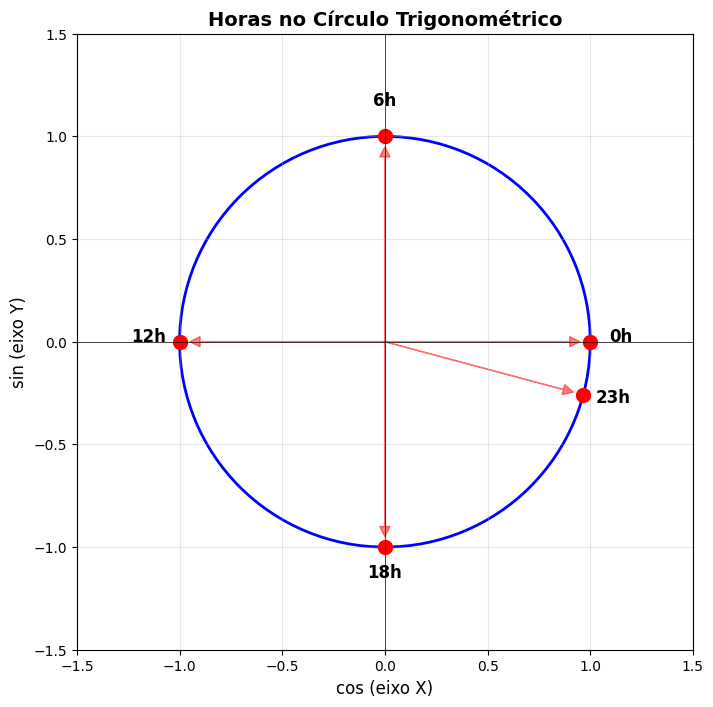

✅ Valores estão CORRETOS segundo círculo trigonométrico! Feature criada corretamente!


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Ver algumas horas no círculo
horas_exemplo = [0, 6, 12, 18, 23]
fig, ax = plt.subplots(figsize=(8, 8))

# Desenhar círculo
circle = plt.Circle((0, 0), 1, fill=False, color='blue', linewidth=2)
ax.add_patch(circle)

# Plotar cada hora
for hour in horas_exemplo:
    sin_val = df[df['Hour'] == hour]['hour_sin'].iloc[0]
    cos_val = df[df['Hour'] == hour]['hour_cos'].iloc[0]
    
    ax.plot(cos_val, sin_val, 'ro', markersize=10)
    ax.text(cos_val*1.15, sin_val*1.15, f'{hour}h', 
            fontsize=12, ha='center', fontweight='bold')
    ax.arrow(0, 0, cos_val*0.9, sin_val*0.9, 
             head_width=0.05, head_length=0.05, fc='red', ec='red', alpha=0.5)

# Configurar
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('cos (eixo X)', fontsize=12)
ax.set_ylabel('sin (eixo Y)', fontsize=12)
ax.set_title('Horas no Círculo Trigonométrico', fontsize=14, fontweight='bold')

plt.show()

print("✅ Valores estão CORRETOS segundo círculo trigonométrico! Feature criada corretamente!")

In [9]:
df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Lagging_Current_Power_Factor,WeekStatus,Day_Of_Week,Load_Type,Hour,Month,DayOfMonth,is_peak_operational,hour_sin,hour_cos
0,2018-01-01 00:15:00,3.17,2.95,73.21,Weekday,Monday,Light_Load,0,1,1,0,0.000000,1.000000
1,2018-01-01 00:30:00,4.00,4.46,66.77,Weekday,Monday,Light_Load,0,1,1,0,0.000000,1.000000
2,2018-01-01 00:45:00,3.24,3.28,70.28,Weekday,Monday,Light_Load,0,1,1,0,0.000000,1.000000
3,2018-01-01 01:00:00,3.31,3.56,68.09,Weekday,Monday,Light_Load,1,1,1,0,0.258819,0.965926
4,2018-01-01 01:15:00,3.82,4.50,64.72,Weekday,Monday,Light_Load,1,1,1,0,0.258819,0.965926


#Encoding do Load type

Load_Type é categórico (texto):
- Light_Load
- Medium_Load  
- Maximum_Load

Light_Load    → substituir por 8.6 kWh (média de consumo quando é Light)

Medium_Load   → substituir por 38.4 kWh (média quando é Medium)

Maximum_Load  → substituir por 59.3 kWh (média quando é Maximum)

Estou colocando dessa forma e não por one hot encoding, com o intuito que modelo de ML entenda que existe uma hierarquia entre as cargas!

In [10]:
#calculando a média de consumo por cada loaf_type

medias_por_load = df.groupby('Load_Type')['Usage_kWh'].mean()
print("📊 CONSUMO MÉDIO POR LOAD TYPE:")
print(medias_por_load.sort_values())

📊 CONSUMO MÉDIO POR LOAD TYPE:
Load_Type
Light_Load       8.625959
Medium_Load     38.445394
Maximum_Load    59.265314
Name: Usage_kWh, dtype: float64


In [11]:
#criando uma nova coluna com valores numéricos

df['load_type_encoded'] = df['Load_Type'].map(medias_por_load)

print("\nComparando as colunas:")
print(df[['Load_Type', 'load_type_encoded', 'Usage_kWh']].head())


Comparando as colunas:
    Load_Type  load_type_encoded  Usage_kWh
0  Light_Load           8.625959       3.17
1  Light_Load           8.625959       4.00
2  Light_Load           8.625959       3.24
3  Light_Load           8.625959       3.31
4  Light_Load           8.625959       3.82


In [12]:
#verificando a correlação com a target

correlacao = df['load_type_encoded'].corr(df['Usage_kWh'])

print("📈 CORRELAÇÃO COM TARGET:")
print(f"   load_type_encoded × Usage_kWh = {correlacao:.3f}")

📈 CORRELAÇÃO COM TARGET:
   load_type_encoded × Usage_kWh = 0.617


In [13]:
# Ver a VARIAÇÃO dentro de cada Load_Type
print("📊 ESTATÍSTICAS POR LOAD TYPE:\n")

for load_type in ['Light_Load', 'Medium_Load', 'Maximum_Load']:
    subset = df[df['Load_Type'] == load_type]['Usage_kWh']
    
    print(f"{load_type}:")
    print(f"  Média:   {subset.mean():.2f} kWh")
    print(f"  Mínimo:  {subset.min():.2f} kWh")
    print(f"  Máximo:  {subset.max():.2f} kWh")
    print(f"  Range:   {subset.max() - subset.min():.2f} kWh ← VARIAÇÃO!")
    print()

📊 ESTATÍSTICAS POR LOAD TYPE:

Light_Load:
  Média:   8.63 kWh
  Mínimo:  0.00 kWh
  Máximo:  140.29 kWh
  Range:   140.29 kWh ← VARIAÇÃO!

Medium_Load:
  Média:   38.45 kWh
  Mínimo:  2.52 kWh
  Máximo:  157.18 kWh
  Range:   154.66 kWh ← VARIAÇÃO!

Maximum_Load:
  Média:   59.27 kWh
  Mínimo:  2.92 kWh
  Máximo:  151.67 kWh
  Range:   148.75 kWh ← VARIAÇÃO!



##Vendo se é final de semana

In [14]:
# Ver a coluna WeekStatus atual
print("📊 COLUNA WEEKSTATUS:")
print(df['WeekStatus'].value_counts())

📊 COLUNA WEEKSTATUS:
WeekStatus
Weekday    25057
Weekend     9984
Name: count, dtype: int64


In [18]:
#criando uma coluna pra colocar 1 se for final de semana e 0 se for dia da semana

df['is_weekend'] = (df['WeekStatus'] == 'Weekend').astype(int)
print(df[['WeekStatus', 'is_weekend', 'Usage_kWh']].head(10))
print(f'\n{df['is_weekend'].value_counts()}')


  WeekStatus  is_weekend  Usage_kWh
0    Weekday           0       3.17
1    Weekday           0       4.00
2    Weekday           0       3.24
3    Weekday           0       3.31
4    Weekday           0       3.82
5    Weekday           0       3.28
6    Weekday           0       3.60
7    Weekday           0       3.60
8    Weekday           0       3.28
9    Weekday           0       3.78

is_weekend
0    25057
1     9984
Name: count, dtype: int64
